In [5]:
import json
import pandas as pd
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
sample_paths = {
    "video_gold": Path("/work/courses/3dv/team1/lmms-eval/outputs/oos_videoqa/Qwen__Qwen3-VL-4B-Instruct/20260430_170035_samples_oos_videoqa.jsonl"),
    "video_pred": Path("/work/courses/3dv/team1/lmms-eval/outputs/oos_videoqa/Qwen__Qwen3-VL-4B-Instruct/20260430_182942_samples_oos_videoqa.jsonl"),
    "no_videos": Path("/work/courses/3dv/team1/lmms-eval/outputs/oos_videoqa/Qwen__Qwen3-VL-4B-Instruct/20260430_071443_samples_oos_videoqa.jsonl"),
}

def load_sample_file(path):
    rows = []
    with path.open("r") as f:
        for line in f:
            d = json.loads(line)
            s = d.get("oos_score", {})

            row = {
                "doc_id": d.get("doc_id"),
                "target": d.get("target"),
                "prediction": d.get("filtered_resps"),
                "input": d.get("input"),

                "trajectory_id": s.get("trajectory_id"),
                "step": str(s.get("step")),
                "question_class": s.get("step_question_class"),
                "question": s.get("question"),
                "choices": s.get("choices"),
                "gold_idx": s.get("gold_idx"),
                "gold_choice": s.get("gold_choice"),
                "pred_idx": s.get("pred_idx"),
                "pred_choice": s.get("pred_choice"),
                "accuracy": s.get("accuracy"),
                "parsed": s.get("parsed"),

                "pred_time_sec": s.get("pred_time_sec"),
                "gold_time_sec": s.get("gold_time_sec"),
                "time_error_sec": s.get("time_error_sec"),
                "pred_point_x": s.get("pred_point_x"),
                "pred_point_y": s.get("pred_point_y"),
                "gold_point_x": s.get("gold_point_x"),
                "gold_point_y": s.get("gold_point_y"),
                "coord_error_linf": s.get("coord_error_linf"),
                "time_within_tolerance": s.get("time_within_tolerance"),
                "coord_within_tolerance": s.get("coord_within_tolerance"),
            }
            rows.append(row)

    return pd.DataFrame(rows)

runs = {name: load_sample_file(path) for name, path in sample_paths.items()}

for name, rdf in runs.items():
    print("\n" + "=" * 100)
    print(name, "rows:", len(rdf))
    print(rdf.groupby("question_class")["accuracy"].mean())


video_gold rows: 770
question_class
oos_branch_object_camera_relative_position    0.272727
oos_branch_object_object_distance             0.145455
oos_branch_object_object_relation             0.363636
oos_step1_visibility                          0.918182
oos_step2_last_visible                        0.009091
oos_step3_last_placement                      0.072727
oos_step4_fixture                             0.690909
Name: accuracy, dtype: float64

video_pred rows: 770
question_class
oos_branch_object_camera_relative_position    0.281818
oos_branch_object_object_distance             0.172727
oos_branch_object_object_relation             0.390909
oos_step1_visibility                          0.918182
oos_step2_last_visible                        0.009091
oos_step3_last_placement                      0.036364
oos_step4_fixture                             0.690909
Name: accuracy, dtype: float64

no_videos rows: 770
question_class
oos_branch_object_camera_relative_position    0.436364
oos

Prediction distribution

In [ ]:
for name, rdf in runs.items():
    if len(rdf) < 100:
        continue

    print("\n" + "#" * 100)
    print(name)

    for qclass, g in rdf.groupby("question_class"):
        print("\n" + qclass)
        print("Gold:")
        print(g["gold_choice"].value_counts(dropna=False).head(20))
        print("Pred:")
        print(g["pred_choice"].value_counts(dropna=False).head(20))


####################################################################################################
video_gold

oos_branch_object_camera_relative_position
Gold:
gold_choice
Back-right     52
Back-left      24
Front-right    18
Front-left     16
Name: count, dtype: int64
Pred:
pred_choice
Back-left      75
Back-right     34
Front-right     1
Name: count, dtype: int64

oos_branch_object_object_distance
Gold:
gold_choice
medium        79
close         15
far           13
very close     3
Name: count, dtype: int64
Pred:
pred_choice
far           105
medium          3
very close      2
Name: count, dtype: int64

oos_branch_object_object_relation
Gold:
gold_choice
Back-right     66
Back-left      40
Front-right     2
Front-left      2
Name: count, dtype: int64
Pred:
pred_choice
Back-left    110
Name: count, dtype: int64

oos_step1_visibility
Gold:
gold_choice
No    110
Name: count, dtype: int64
Pred:
pred_choice
No     101
Yes      9
Name: count, dtype: int64

oos_step2_last_visible
Gold:


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_compare_modes_by_question_type(runs, normalize=False):
    """
    For each question class, compare:
      - Gold distribution
      - Pred distribution from each run/mode

    runs: dict like
      {
        "video_gold": df,
        "video_pred": df,
        "no_videos": df,
      }
    """

    # Collect all question classes from all runs
    all_qclasses = sorted(set(
        qclass
        for rdf in runs.values()
        for qclass in rdf["question_class"].dropna().unique()
    ))

    # Skip open-ended time/point steps here
    skip_qclasses = {
        "oos_step2_last_visible",
        "oos_step3_last_placement",
    }
    qclasses = [q for q in all_qclasses if q not in skip_qclasses]

    n = len(qclasses)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, qclass in zip(axes, qclasses):
        # Use first available run to get gold distribution
        first_run_name = next(iter(runs))
        gold_df = runs[first_run_name]
        g0 = gold_df[gold_df["question_class"] == qclass].copy()

        gold_counts = g0["gold_choice"].fillna("UNPARSED").value_counts()

        # Collect predicted counts from each run
        pred_counts_by_run = {}
        labels = set(gold_counts.index)

        for run_name, rdf in runs.items():
            g = rdf[rdf["question_class"] == qclass].copy()
            pred_counts = g["pred_choice"].fillna("UNPARSED").value_counts()
            pred_counts_by_run[run_name] = pred_counts
            labels.update(pred_counts.index)

        labels = list(labels)

        # Nice label ordering for common answer sets
        preferred_orders = [
            ["No", "Yes", "UNPARSED"],
            ["Front-left", "Front-right", "Back-left", "Back-right", "UNPARSED"],
            ["very close", "close", "medium", "far", "UNPARSED"],
        ]

        for order in preferred_orders:
            if any(label in order for label in labels):
                labels = [x for x in order if x in labels] + [x for x in labels if x not in order]
                break
        else:
            labels = sorted(labels)

        # Build plot dataframe
        plot_dict = {
            "Gold": [gold_counts.get(label, 0) for label in labels]
        }

        for run_name, pred_counts in pred_counts_by_run.items():
            plot_dict[f"Pred:{run_name}"] = [pred_counts.get(label, 0) for label in labels]

        plot_df = pd.DataFrame(plot_dict, index=labels)

        if normalize:
            n_examples = len(g0)
            if n_examples > 0:
                plot_df = plot_df / n_examples

        plot_df.plot(kind="bar", ax=ax)

        # Show accuracies in title
        acc_parts = []
        for run_name, rdf in runs.items():
            g = rdf[rdf["question_class"] == qclass].copy()
            if len(g) > 0 and "accuracy" in g.columns:
                acc_parts.append(f"{run_name}={g['accuracy'].mean():.3f}")

        title = qclass
        if acc_parts:
            title += "\n" + ", ".join(acc_parts)

        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("Proportion" if normalize else "Count")
        ax.tick_params(axis="x", rotation=35)
        ax.legend(title="Distribution")

    # Hide unused axes
    for ax in axes[len(qclasses):]:
        ax.axis("off")

    fig.suptitle("Compare modes by question type", fontsize=16)
    plt.tight_layout()
    plt.show()

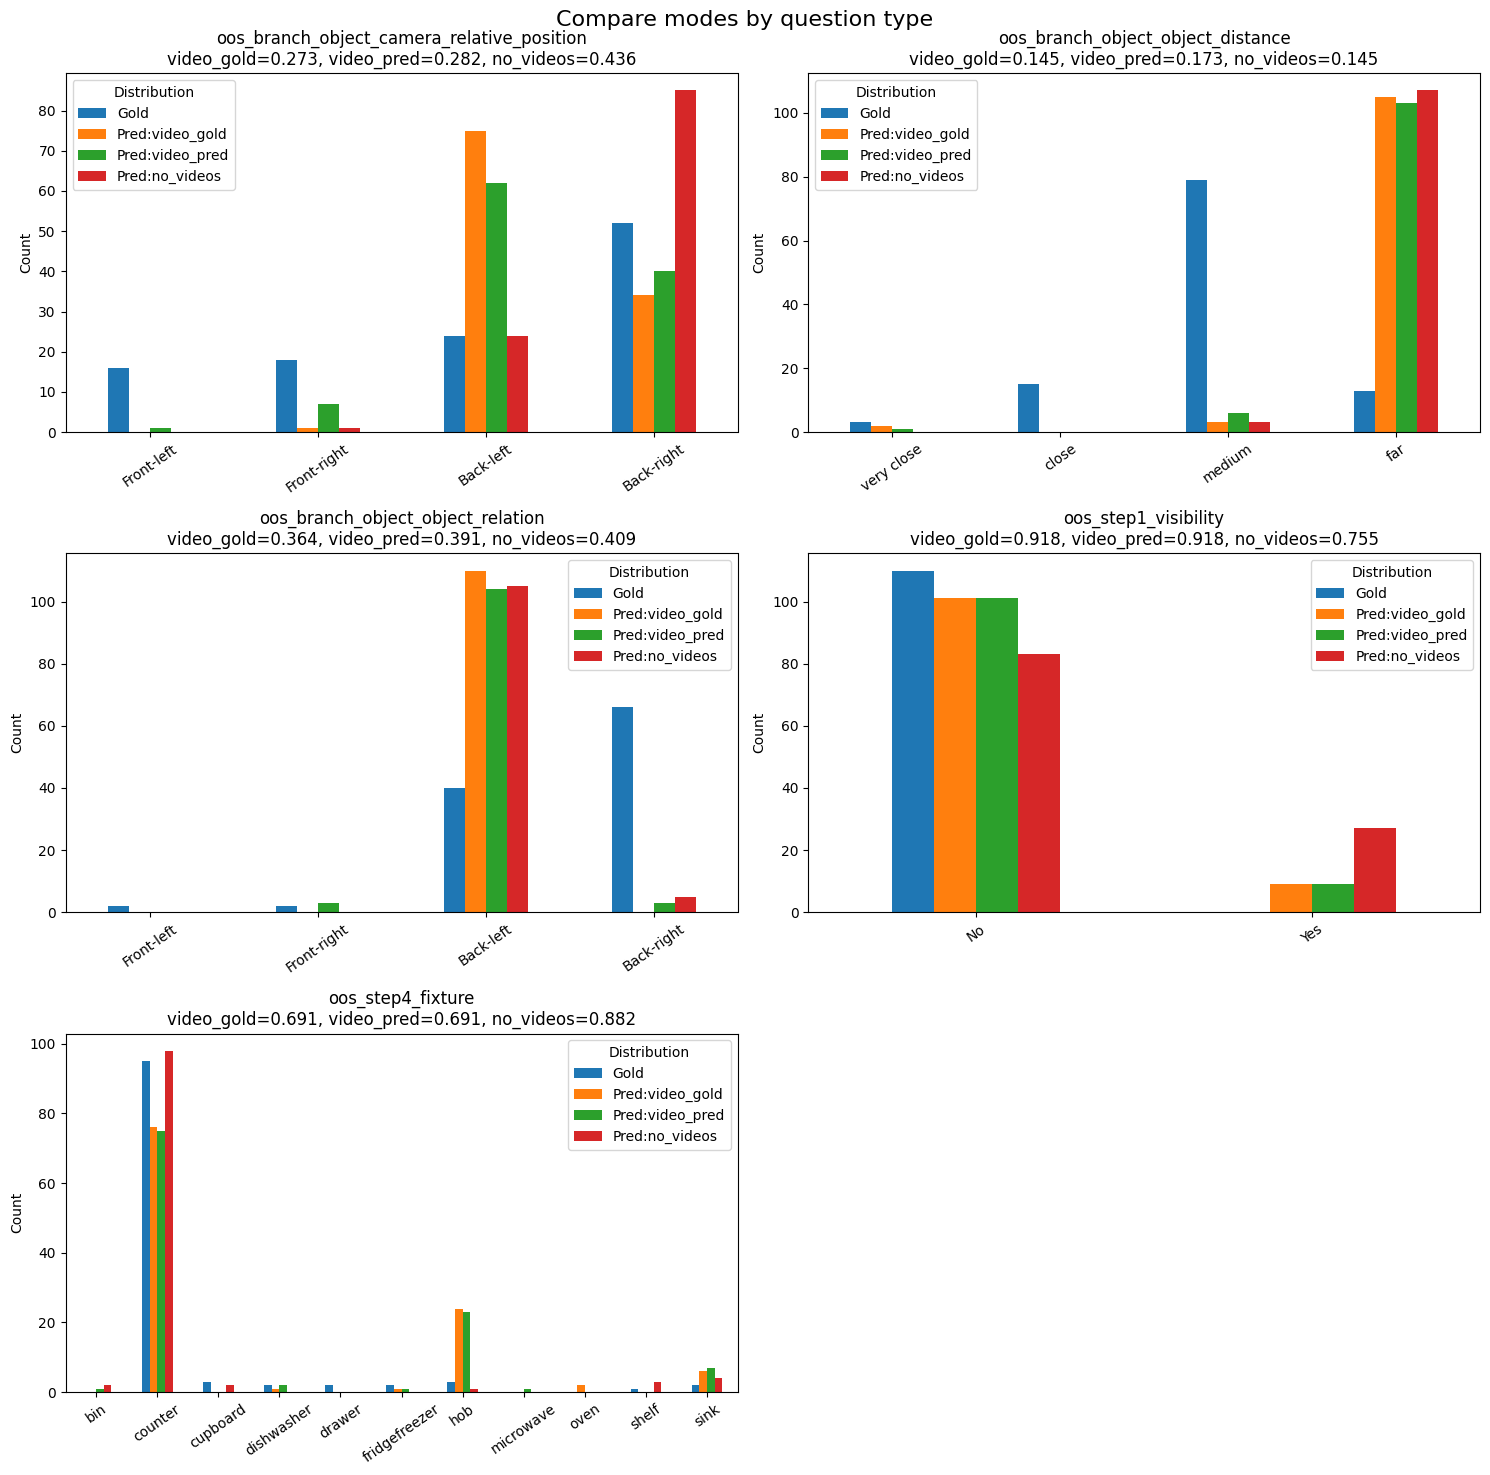

In [12]:
plot_compare_modes_by_question_type(
    runs,
    normalize=False,
)

In [13]:
for name, rdf in runs.items():
    if len(rdf) < 100:
        continue

    print("\n" + "#" * 100)
    print(name)

    for qclass in [
        "oos_step4_fixture",
        "oos_branch_object_object_distance",
        "oos_branch_object_object_relation",
        "oos_branch_object_camera_relative_position",
    ]:
        g = rdf[rdf["question_class"] == qclass]

        print("\n" + "=" * 80)
        print(qclass)
        print(pd.crosstab(
            g["gold_choice"],
            g["pred_choice"],
            rownames=["gold"],
            colnames=["pred"],
            dropna=False,
        ))


####################################################################################################
video_gold

oos_step4_fixture
pred           counter  dishwasher  fridgefreezer  hob  oven  sink
gold                                                              
counter             71           0              0   20     2     2
cupboard             1           0              0    0     0     2
dishwasher           0           1              0    0     0     1
drawer               1           0              1    0     0     0
fridgefreezer        2           0              0    0     0     0
hob                  0           0              0    3     0     0
shelf                1           0              0    0     0     0
sink                 0           0              0    1     0     1

oos_branch_object_object_distance
pred        far  medium  very close
gold                               
close        14       0           1
far          13       0           0
medium       75    

In [4]:
for name, rdf in runs.items():
    if len(rdf) < 100:
        continue

    print("\n" + "#" * 100)
    print(name)

    for qclass in ["oos_step2_last_visible", "oos_step3_last_placement"]:
        g = rdf[rdf["question_class"] == qclass].copy()

        print("\n" + "=" * 80)
        print(qclass)
        print("N:", len(g))
        print("accuracy:", g["accuracy"].mean())
        print("parsed:", g["parsed"].mean())
        print("time ok:", g["time_within_tolerance"].mean())
        print("coord ok:", g["coord_within_tolerance"].mean())

        print("\nTime error summary:")
        print(g["time_error_sec"].describe())

        print("\nCoord error summary:")
        print(g["coord_error_linf"].describe())

        display_cols = [
            "trajectory_id",
            "step",
            "gold_choice",
            "prediction",
            "pred_time_sec",
            "gold_time_sec",
            "time_error_sec",
            "pred_point_x",
            "pred_point_y",
            "gold_point_x",
            "gold_point_y",
            "coord_error_linf",
            "accuracy",
        ]

        display(g[display_cols].head(10))


####################################################################################################
video_gold

oos_step2_last_visible
N: 110
accuracy: 0.00909090909090909
parsed: 1.0
time ok: 0.00909090909090909
coord ok: 0.20909090909090908

Time error summary:
count    110.000000
mean     261.690909
std      226.383808
min        2.000000
25%      101.000000
50%      180.000000
75%      397.750000
max      819.000000
Name: time_error_sec, dtype: float64

Coord error summary:
count    110.000000
mean       0.330821
std        0.156069
min        0.029489
25%        0.213854
50%        0.338844
75%        0.437826
max        0.716060
Name: coord_error_linf, dtype: float64


,trajectory_id,step,gold_choice,prediction,pred_time_sec,gold_time_sec,time_error_sec,pred_point_x,pred_point_y,gold_point_x,gold_point_y,coord_error_linf,accuracy
1,P01-20240202-110250__oos_staged_h5p0_0,2,"<TIME 00:01:00.0 video 1>; Point=(0.6107, 0.7685)","<TIME 00:00:50.0 video 1>; Point=(0.52, 0.52)",50.0,60.0,10.0,0.52,0.52,0.610713,0.768473,0.248473,0.0
8,P01-20240202-110250__oos_staged_h5p0_1,2,"<TIME 00:01:03.0 video 1>; Point=(0.1006, 0.7887)","<TIME 00:00:24.0 video 1>; Point=(0.37, 0.45)",24.0,63.0,39.0,0.37,0.45,0.100566,0.788746,0.338746,0.0
15,P01-20240202-110250__oos_staged_h5p0_2,2,"<TIME 00:01:03.0 video 1>; Point=(0.2443, 0.6606)","<TIME 00:00:24.0 video 1>; Point=(0.52, 0.62)",24.0,63.0,39.0,0.52,0.62,0.244342,0.660626,0.275658,0.0
22,P01-20240202-110250__oos_staged_h5p0_3,2,"<TIME 00:01:03.0 video 1>; Point=(0.0566, 0.633)","<TIME 00:00:28.0 video 1>; Point=(0.45, 0.62)",28.0,63.0,35.0,0.45,0.62,0.056586,0.632979,0.393414,0.0
29,P01-20240202-110250__oos_staged_h5p0_4,2,"<TIME 00:01:27.0 video 1>; Point=(0.4358, 0.8498)","<TIME 00:00:47.0 video 1>; Point=(0.51, 0.71)",47.0,87.0,40.0,0.51,0.71,0.435756,0.849750,0.139750,0.0
36,P01-20240202-110250__oos_staged_h5p0_5,2,"<TIME 00:01:53.0 video 1>; Point=(0.9171, 0.5945)","<TIME 00:01:00.0 video 1>; Point=(0.58, 0.58)",60.0,113.0,53.0,0.58,0.58,0.917063,0.594461,0.337063,0.0
43,P01-20240202-110250__oos_staged_h5p0_6,2,"<TIME 00:01:53.0 video 1>; Point=(0.9158, 0.5945)","<TIME 00:00:52.0 video 1>; Point=(0.58, 0.58)",52.0,113.0,61.0,0.58,0.58,0.915760,0.594525,0.335760,0.0
50,P01-20240202-110250__oos_staged_h5p0_7,2,"<TIME 00:01:58.0 video 1>; Point=(0.547, 0.8339)","<TIME 00:00:00.0 video 1>; Point=(0.45, 0.62)",0.0,118.0,118.0,0.45,0.62,0.547024,0.833854,0.213854,0.0
57,P01-20240202-110250__oos_staged_h5p0_8,2,"<TIME 00:02:14.0 video 1>; Point=(0.6749, 0.5442)","<TIME 00:00:00.0 video 1>; Point=(0.45, 0.62)",0.0,134.0,134.0,0.45,0.62,0.674943,0.544192,0.224943,0.0
64,P01-20240202-110250__oos_staged_h5p0_9,2,"<TIME 00:02:14.0 video 1>; Point=(0.7271, 0.739)","<TIME 00:00:50.0 video 1>; Point=(0.51, 0.72)",50.0,134.0,84.0,0.51,0.72,0.727058,0.739036,0.217058,0.0



oos_step3_last_placement
N: 110
accuracy: 0.07272727272727272
parsed: 1.0
time ok: 0.09090909090909091
coord ok: 0.41818181818181815

Time error summary:
count    110.000000
mean     130.360606
std      137.666635
min        0.200000
25%       24.025000
50%       82.183333
75%      215.991667
max      722.933333
Name: time_error_sec, dtype: float64

Coord error summary:
count    110.000000
mean       0.243206
std        0.136711
min        0.019024
25%        0.140355
50%        0.211546
75%        0.328440
max        0.686947
Name: coord_error_linf, dtype: float64


,trajectory_id,step,gold_choice,prediction,pred_time_sec,gold_time_sec,time_error_sec,pred_point_x,pred_point_y,gold_point_x,gold_point_y,coord_error_linf,accuracy
2,P01-20240202-110250__oos_staged_h5p0_0,3,"<TIME 00:00:58.2 video 1>; Point=(0.5579, 0.7974)","<TIME 00:00:58.0 video 1>; Point=(0.6107, 0.7685)",58.0,58.200000,0.200000,0.6107,0.7685,0.557895,0.797390,0.052805,1.0
9,P01-20240202-110250__oos_staged_h5p0_1,3,"<TIME 00:00:14.6 video 1>; Point=(0.5932, 0.8304)","<TIME 00:00:00.0 video 1>; Point=(0.1006, 0.7887)",0.0,14.600000,14.600000,0.1006,0.7887,0.593215,0.830388,0.492615,0.0
16,P01-20240202-110250__oos_staged_h5p0_2,3,"<TIME 00:00:25.4 video 1>; Point=(0.5371, 0.7578)","<TIME 00:00:00.0 video 1>; Point=(0.45, 0.62)",0.0,25.400000,25.400000,0.4500,0.6200,0.537133,0.757842,0.137842,0.0
23,P01-20240202-110250__oos_staged_h5p0_3,3,"<TIME 00:00:17.1 video 1>; Point=(0.5794, 0.6939)","<TIME 00:00:00.0 video 1>; Point=(0.45, 0.62)",0.0,17.066667,17.066667,0.4500,0.6200,0.579442,0.693916,0.129442,0.0
30,P01-20240202-110250__oos_staged_h5p0_4,3,"<TIME 00:01:29.0 video 1>; Point=(0.4887, 0.7185)","<TIME 00:01:27.0 video 1>; Point=(0.4358, 0.8498)",87.0,89.000000,2.000000,0.4358,0.8498,0.488671,0.718453,0.131347,1.0
37,P01-20240202-110250__oos_staged_h5p0_5,3,"<TIME 00:00:58.2 video 1>; Point=(0.5579, 0.7974)","<TIME 00:01:53.0 video 1>; Point=(0.9171, 0.5945)",113.0,58.200000,54.800000,0.9171,0.5945,0.557895,0.797390,0.359205,0.0
44,P01-20240202-110250__oos_staged_h5p0_6,3,"<TIME 00:00:52.8 video 1>; Point=(0.5858, 0.7787)","<TIME 00:00:53.0 video 1>; Point=(0.52, 0.52)",53.0,52.766667,0.233333,0.5200,0.5200,0.585815,0.778653,0.258653,0.0
51,P01-20240202-110250__oos_staged_h5p0_7,3,"<TIME 00:01:57.5 video 1>; Point=(0.5264, 0.8036)","<TIME 00:01:58.0 video 1>; Point=(0.5470, 0.8339)",118.0,117.500000,0.500000,0.5470,0.8339,0.526363,0.803622,0.030278,1.0
58,P01-20240202-110250__oos_staged_h5p0_8,3,"<TIME 00:01:12.5 video 1>; Point=(0.2428, 0.6645)","<TIME 00:01:30.0 video 1>; Point=(0.6749, 0.5442)",90.0,72.466667,17.533333,0.6749,0.5442,0.242816,0.664472,0.432084,0.0
65,P01-20240202-110250__oos_staged_h5p0_9,3,"<TIME 00:02:07.6 video 1>; Point=(0.5699, 0.8163)","<TIME 00:02:14.0 video 1>; Point=(0.7271, 0.7390)",134.0,127.600000,6.400000,0.7271,0.7390,0.569858,0.816308,0.157242,0.0



####################################################################################################
video_pred

oos_step2_last_visible
N: 110
accuracy: 0.00909090909090909
parsed: 1.0
time ok: 0.00909090909090909
coord ok: 0.21818181818181817

Time error summary:
count    110.000000
mean     259.481818
std      224.015470
min        2.000000
25%      101.500000
50%      175.000000
75%      390.750000
max      819.000000
Name: time_error_sec, dtype: float64

Coord error summary:
count    110.000000
mean       0.342646
std        0.178841
min        0.029489
25%        0.213328
50%        0.380684
75%        0.439628
max        0.780474
Name: coord_error_linf, dtype: float64


...

,trajectory_id,step,gold_choice,prediction,pred_time_sec,gold_time_sec,time_error_sec,pred_point_x,pred_point_y,gold_point_x,gold_point_y,coord_error_linf,accuracy
2,P01-20240202-110250__oos_staged_h5p0_0,3,"<TIME 00:00:58.2 video 1>; Point=(0.5579, 0.7974)","<TIME 00:00:52.0 video 1>; Point=(0.52, 0.52)",52.0,58.200000,6.200000,0.52,0.52,0.557895,0.797390,0.277390,0.0
9,P01-20240202-110250__oos_staged_h5p0_1,3,"<TIME 00:00:14.6 video 1>; Point=(0.5932, 0.8304)","<TIME 00:00:24.0 video 1>; Point=(0.37, 0.37)",24.0,14.600000,9.400000,0.37,0.37,0.593215,0.830388,0.460388,0.0
16,P01-20240202-110250__oos_staged_h5p0_2,3,"<TIME 00:00:25.4 video 1>; Point=(0.5371, 0.7578)","<TIME 00:00:24.0 video 1>; Point=(0.51, 0.68)",24.0,25.400000,1.400000,0.51,0.68,0.537133,0.757842,0.077842,1.0
23,P01-20240202-110250__oos_staged_h5p0_3,3,"<TIME 00:00:17.1 video 1>; Point=(0.5794, 0.6939)","<TIME 00:00:28.0 video 1>; Point=(0.45, 0.62)",28.0,17.066667,10.933333,0.45,0.62,0.579442,0.693916,0.129442,0.0
30,P01-20240202-110250__oos_staged_h5p0_4,3,"<TIME 00:01:29.0 video 1>; Point=(0.4887, 0.7185)","<TIME 00:00:47.0 video 1>; Point=(0.51, 0.78)",47.0,89.000000,42.000000,0.51,0.78,0.488671,0.718453,0.061547,0.0
37,P01-20240202-110250__oos_staged_h5p0_5,3,"<TIME 00:00:58.2 video 1>; Point=(0.5579, 0.7974)","<TIME 00:00:59.0 video 1>; Point=(0.62, 0.52)",59.0,58.200000,0.800000,0.62,0.52,0.557895,0.797390,0.277390,0.0
44,P01-20240202-110250__oos_staged_h5p0_6,3,"<TIME 00:00:52.8 video 1>; Point=(0.5858, 0.7787)","<TIME 00:00:52.0 video 1>; Point=(0.52, 0.52)",52.0,52.766667,0.766667,0.52,0.52,0.585815,0.778653,0.258653,0.0
51,P01-20240202-110250__oos_staged_h5p0_7,3,"<TIME 00:01:57.5 video 1>; Point=(0.5264, 0.8036)","<TIME 00:00:00.0 video 1>; Point=(0.12, 0.12)",0.0,117.500000,117.500000,0.12,0.12,0.526363,0.803622,0.683622,0.0
58,P01-20240202-110250__oos_staged_h5p0_8,3,"<TIME 00:01:12.5 video 1>; Point=(0.2428, 0.6645)","<TIME 00:01:30.0 video 1>; Point=(0.45, 0.62)",90.0,72.466667,17.533333,0.45,0.62,0.242816,0.664472,0.207184,0.0
65,P01-20240202-110250__oos_staged_h5p0_9,3,"<TIME 00:02:07.6 video 1>; Point=(0.5699, 0.8163)","<TIME 00:00:50.0 video 1>; Point=(0.52, 0.72)",50.0,127.600000,77.600000,0.52,0.72,0.569858,0.816308,0.096308,0.0



####################################################################################################
no_videos

oos_step2_last_visible
N: 110
accuracy: 0.03636363636363636
parsed: 1.0
time ok: 0.09090909090909091
coord ok: 0.2909090909090909

Time error summary:
count    110.000000
mean      16.200000
std       12.931577
min        0.000000
25%        5.000000
50%        5.000000
75%       30.000000
max       36.000000
Name: time_error_sec, dtype: float64

Coord error summary:
count    110.000000
mean       0.347319
std        0.188337
min        0.052942
25%        0.185802
50%        0.323103
75%        0.496420
max        0.772740
Name: coord_error_linf, dtype: float64


,trajectory_id,step,gold_choice,prediction,pred_time_sec,gold_time_sec,time_error_sec,pred_point_x,pred_point_y,gold_point_x,gold_point_y,coord_error_linf,accuracy
1,P01-20240202-110250__oos_staged_h5p0_0,2,"<TIME 00:01:00.0 video 1>; Point=(0.6107, 0.7685)","<TIME 00:00:58.0 video 1>; Point=(0.68, 0.72)",58.0,60.0,2.0,0.68,0.72,0.610713,0.768473,0.069287,1.0
8,P01-20240202-110250__oos_staged_h5p0_1,2,"<TIME 00:01:03.0 video 1>; Point=(0.1006, 0.7887)","<TIME 00:01:08.0 video 1>; Point=(0.32, 0.78)",68.0,63.0,5.0,0.32,0.78,0.100566,0.788746,0.219434,0.0
15,P01-20240202-110250__oos_staged_h5p0_2,2,"<TIME 00:01:03.0 video 1>; Point=(0.2443, 0.6606)","<TIME 00:00:58.0 video 1>; Point=(0.32, 0.78)",58.0,63.0,5.0,0.32,0.78,0.244342,0.660626,0.119374,0.0
22,P01-20240202-110250__oos_staged_h5p0_3,2,"<TIME 00:01:03.0 video 1>; Point=(0.0566, 0.633)","<TIME 00:01:08.0 video 1>; Point=(0.32, 0.78)",68.0,63.0,5.0,0.32,0.78,0.056586,0.632979,0.263414,0.0
29,P01-20240202-110250__oos_staged_h5p0_4,2,"<TIME 00:01:27.0 video 1>; Point=(0.4358, 0.8498)","<TIME 00:01:34.0 video 1>; Point=(0.32, 0.78)",94.0,87.0,7.0,0.32,0.78,0.435756,0.849750,0.115756,0.0
36,P01-20240202-110250__oos_staged_h5p0_5,2,"<TIME 00:01:53.0 video 1>; Point=(0.9171, 0.5945)","<TIME 00:01:58.0 video 1>; Point=(0.68, 0.71)",118.0,113.0,5.0,0.68,0.71,0.917063,0.594461,0.237063,0.0
43,P01-20240202-110250__oos_staged_h5p0_6,2,"<TIME 00:01:53.0 video 1>; Point=(0.9158, 0.5945)","<TIME 00:01:58.0 video 1>; Point=(0.32, 0.78)",118.0,113.0,5.0,0.32,0.78,0.915760,0.594525,0.595760,0.0
50,P01-20240202-110250__oos_staged_h5p0_7,2,"<TIME 00:01:58.0 video 1>; Point=(0.547, 0.8339)","<TIME 00:01:58.0 video 1>; Point=(0.32, 0.78)",118.0,118.0,0.0,0.32,0.78,0.547024,0.833854,0.227024,0.0
57,P01-20240202-110250__oos_staged_h5p0_8,2,"<TIME 00:02:14.0 video 1>; Point=(0.6749, 0.5442)","<TIME 00:02:18.0 video 1>; Point=(0.32, 0.78)",138.0,134.0,4.0,0.32,0.78,0.674943,0.544192,0.354943,0.0
64,P01-20240202-110250__oos_staged_h5p0_9,2,"<TIME 00:02:14.0 video 1>; Point=(0.7271, 0.739)","<TIME 00:02:18.0 video 1>; Point=(0.78, 0.71)",138.0,134.0,4.0,0.78,0.71,0.727058,0.739036,0.052942,0.0



oos_step3_last_placement
N: 110
accuracy: 0.10909090909090909
parsed: 1.0
time ok: 0.10909090909090909
coord ok: 0.3181818181818182

Time error summary:
count    110.000000
mean     154.438182
std      165.328096
min        0.133333
25%       29.591667
50%       82.883333
75%      238.275000
max      717.533333
Name: time_error_sec, dtype: float64

Coord error summary:
count    110.000000
mean       0.295737
std        0.177489
min        0.019024
25%        0.164821
50%        0.259827
75%        0.398485
max        0.817776
Name: coord_error_linf, dtype: float64


,trajectory_id,step,gold_choice,prediction,pred_time_sec,gold_time_sec,time_error_sec,pred_point_x,pred_point_y,gold_point_x,gold_point_y,coord_error_linf,accuracy
2,P01-20240202-110250__oos_staged_h5p0_0,3,"<TIME 00:00:58.2 video 1>; Point=(0.5579, 0.7974)","<TIME 00:01:00.0 video 1>; Point=(0.6107, 0.7685)",60.0,58.200000,1.800000,0.6107,0.7685,0.557895,0.797390,0.052805,1.0
9,P01-20240202-110250__oos_staged_h5p0_1,3,"<TIME 00:00:14.6 video 1>; Point=(0.5932, 0.8304)","<TIME 00:01:03.0 video 1>; Point=(0.1006, 0.7887)",63.0,14.600000,48.400000,0.1006,0.7887,0.593215,0.830388,0.492615,0.0
16,P01-20240202-110250__oos_staged_h5p0_2,3,"<TIME 00:00:25.4 video 1>; Point=(0.5371, 0.7578)","<TIME 00:01:03.0 video 1>; Point=(0.2443, 0.6606)",63.0,25.400000,37.600000,0.2443,0.6606,0.537133,0.757842,0.292833,0.0
23,P01-20240202-110250__oos_staged_h5p0_3,3,"<TIME 00:00:17.1 video 1>; Point=(0.5794, 0.6939)","<TIME 00:01:03.0 video 1>; Point=(0.0566, 0.6330)",63.0,17.066667,45.933333,0.0566,0.6330,0.579442,0.693916,0.522842,0.0
30,P01-20240202-110250__oos_staged_h5p0_4,3,"<TIME 00:01:29.0 video 1>; Point=(0.4887, 0.7185)","<TIME 00:01:27.0 video 1>; Point=(0.4358, 0.8498)",87.0,89.000000,2.000000,0.4358,0.8498,0.488671,0.718453,0.131347,1.0
37,P01-20240202-110250__oos_staged_h5p0_5,3,"<TIME 00:00:58.2 video 1>; Point=(0.5579, 0.7974)","<TIME 00:01:53.0 video 1>; Point=(0.9171, 0.5945)",113.0,58.200000,54.800000,0.9171,0.5945,0.557895,0.797390,0.359205,0.0
44,P01-20240202-110250__oos_staged_h5p0_6,3,"<TIME 00:00:52.8 video 1>; Point=(0.5858, 0.7787)","<TIME 00:01:53.0 video 1>; Point=(0.9158, 0.5945)",113.0,52.766667,60.233333,0.9158,0.5945,0.585815,0.778653,0.329985,0.0
51,P01-20240202-110250__oos_staged_h5p0_7,3,"<TIME 00:01:57.5 video 1>; Point=(0.5264, 0.8036)","<TIME 00:01:58.0 video 1>; Point=(0.5470, 0.8339)",118.0,117.500000,0.500000,0.5470,0.8339,0.526363,0.803622,0.030278,1.0
58,P01-20240202-110250__oos_staged_h5p0_8,3,"<TIME 00:01:12.5 video 1>; Point=(0.2428, 0.6645)","<TIME 00:02:14.0 video 1>; Point=(0.6749, 0.5442)",134.0,72.466667,61.533333,0.6749,0.5442,0.242816,0.664472,0.432084,0.0
65,P01-20240202-110250__oos_staged_h5p0_9,3,"<TIME 00:02:07.6 video 1>; Point=(0.5699, 0.8163)","<TIME 00:02:14.0 video 1>; Point=(0.7271, 0.7390)",134.0,127.600000,6.400000,0.7271,0.7390,0.569858,0.816308,0.157242,0.0
